<a href="https://colab.research.google.com/github/ramvrum/dap-2024/blob/main/les08/rep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №8. Кластеризация

Ирисы Фишера — набор данных для задачи классификации, на примере которого Рональд Фишер в 1936 году продемонстрировал работу разработанного им метода дискриминантного анализа. Иногда его также называют ирисами Андерсона, так как данные были собраны американским ботаником Эдгаром Андерсоном.

In [31]:
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"Python version: {sys.version}")
print(f"Numpy version: {np.version.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Numpy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0


1. Импортируйте модель данных "Ирисы Фишера".

In [32]:
from sklearn.datasets import load_iris

iris = load_iris()

iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


2. Выполните нормализацию данных

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

iris_scaled = scaler.fit_transform(iris_df)

iris_df_scaled = pd.DataFrame(iris_scaled, columns = iris.feature_names)

iris_df_scaled.round(2).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.90,1.02,-1.34,-1.32
1,-1.14,-0.13,-1.34,-1.32
2,-1.39,0.33,-1.40,-1.32
3,-1.51,0.10,-1.28,-1.32
4,-1.02,1.25,-1.34,-1.32


3. Постройте модель кластеризации используя алгоритм  DBSCAN (https://www.youtube.com/watch?v=svAtnZ5XjSI&t=494s), подберите подходящие параметры eps, min_samples

In [39]:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN(eps=1.5, min_samples=8)

feature_sepal_length = iris_df_scaled['sepal length (cm)']
feature_sepal_width  = iris_df_scaled['sepal width (cm)']

cluster_labels = dbscan_model.fit_predict(iris_df_scaled)
cluster_labels


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

4. Постройте диаграмму рассеяния для признаков "sepal length (cm)" "sepal width (cm)", цвет точек на диаграмме должен быть различным для разных кластеров

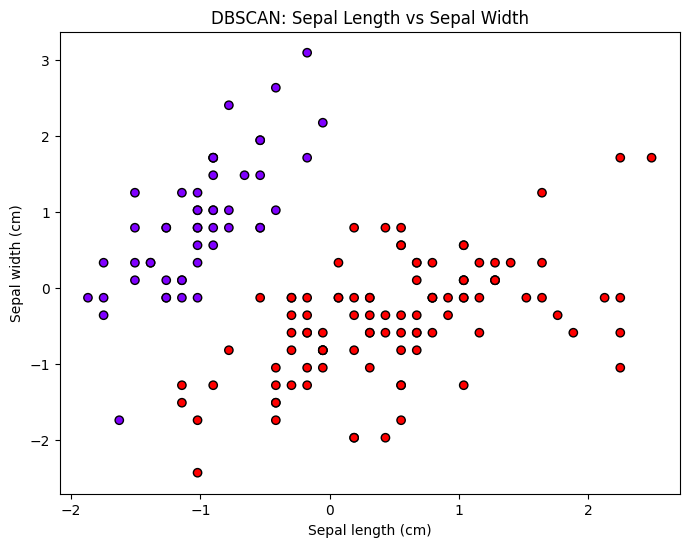

In [40]:
plt.figure(figsize=(8,6))
plt.scatter(feature_sepal_length, feature_sepal_width, c=cluster_labels, cmap='rainbow', edgecolor='k')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.show()

5. Сделайте вывод

Вывод. Построена диаграмма рассеяния для признаков: Sepal length (cm) и Sepal width (cm). Цвет точек соответствует кластеру. На графике видны выделенные кластеры, что позволяет наглядно оценить распределение данных

## Вопросы

1. В чем состоит задача кластеризации?

Задача кластеризации состоит в том, чтобы разделить набор объектов на группы (кластеры) так, чтобы объекты внутри одной группы были максимально похожи друг на друга, а объекты из разных групп — максимально различны

2. Для каких целей используется кластеризацияия?

Кластеризация используется для поиска скрытой структуры в данных, выявления естественных группировок, обнаружения аномалий и упрощения анализа больших наборов данных.

3. Алгоритм кластеризации Ллойда.

Алгоритм кластеризации Ллойда (K-средних) работает следующим образом: сначала выбираются центры кластеров, затем объекты распределяются по ближайшему центру, после чего центры пересчитываются как среднее по принадлежащим им объектам, и процесс повторяется до сходимости, пока центры не перестанут сильно меняться.

4. Как выбрать количество кластеров для алгоритма K-средних

Количество кластеров для алгоритма K-средних выбирается с помощью методов «локтя», оценивая внутрикластерную однородность и межкластерное различие, чтобы определить оптимальное число кластеров.

5. Алгоритм DBSCAN

Алгоритм DBSCAN выполняет кластеризацию на основе плотности: объединяет в кластеры области, где точки находятся близко друг к другу, а точки, не входящие ни в один плотный кластер, отмечает как шум. Параметры алгоритма: eps — максимальное расстояние между соседями, и min_samples — минимальное число точек в плотной области.